# Background Study: Bayesian Hyperparameter Tuning

This notebook introduces the motivation, mathematical basis, data, and experimental workflow for the Bayesian hyperparameter tuning study.

## 1.1 Background

Hyperparameter tuning selects the configuration of a machine-learning algorithm before training. Examples include learning rate, number of trees, tree complexity, regularization strength, and feature subsampling. These choices can substantially affect predictive performance, but they are not learned directly from the training data like model parameters.

Grid search becomes expensive as the number of hyperparameters grows, while random search may spend many evaluations in unpromising regions. This project studies whether Bayesian optimization can find strong configurations with fewer expensive model evaluations.

**Research question:** Can Bayesian optimization identify strong LightGBM hyperparameters with fewer evaluations than random search under the same evaluation budget?

## 1.2 Bayesian Optimization

Bayesian optimization is designed for expensive black-box functions. Here, one evaluation trains a LightGBM classifier and measures its mean cross-validation ROC AUC. Previous observations guide the choice of each new configuration.

Let $\theta$ denote a hyperparameter configuration and let $D_t = \{(\theta_i, y_i)\}_{i=1}^{t}$ denote the observations collected after $t$ trials. Bayes' rule updates the prior belief using the observed data:

$$
p(\theta \mid D_t) = \frac{p(D_t \mid \theta) p(\theta)}{p(D_t)}
$$

The method has two parts:

1. **Surrogate model:** a Gaussian process predicts performance and uncertainty for candidate configurations.
2. **Acquisition function:** a rule balances exploitation of high predicted performance with exploration of uncertain regions.

The expensive evaluation is modeled as a noisy black-box function:

$$
y_i = f(\theta_i) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma_\varepsilon^2)
$$

Here, $f$ is the unknown response surface and $\varepsilon_i$ captures variation from finite validation folds and model randomness. The Gaussian process gives a predictive distribution for a new configuration:

$$
f(\theta) \mid D_t \sim \mathcal{N}\left(\mu_t(\theta), \sigma_t^2(\theta)\right)
$$

A common acquisition rule is expected improvement (EI). If $y_t^+$ is the best objective value observed so far, then:

$$
\operatorname{EI}_t(\theta) = \mathbb{E}\left[\max\left(f(\theta)-y_t^+, 0\right) \mid D_t\right]
$$

For a Gaussian predictive distribution:

$$
\operatorname{EI}_t(\theta) = \left(\mu_t(\theta)-y_t^+\right)\Phi(z_t) + \sigma_t(\theta)\phi(z_t), \qquad z_t = \frac{\mu_t(\theta)-y_t^+}{\sigma_t(\theta)}
$$

where $\Phi$ and $\phi$ are the standard normal cumulative distribution and density functions. The next configuration is selected by maximizing EI:

$$
\theta_{t+1} = \arg\max_{\theta \in \Theta} \operatorname{EI}_t(\theta)
$$

Uncertainty is not the objective by itself. It is useful because the acquisition function combines uncertainty with predicted performance according to the exploration policy.

## 1.3 Dataset

The study uses the **Santander Customer Transaction Prediction** dataset, an anonymized binary classification problem.

| Property | Description |
| --- | --- |
| Observations | 200,000 rows in the processed training file |
| Columns | 202 total columns |
| Predictors | `var_0` through `var_199`, anonymized numerical variables |
| Identifier | `ID_code`, removed before modeling |
| Target | Binary `target` column |
| Primary metric | ROC AUC |

`ID_code` is excluded because it is not a meaningful predictive feature. The target is separated from the predictors, and the data is divided into stratified development and test sets. Hyperparameter optimization uses only the development set. The test set remains untouched until final evaluation.

ROC AUC evaluates ranking quality across classification thresholds and is more informative than raw accuracy when the positive class is imbalanced.

## 1.4 Process Flow

A fixed LightGBM baseline establishes a reference point. Random search and Gaussian-process Bayesian optimization use the same search space, cross-validation strategy, and approximate evaluation budget. The selected configuration is refit on development data and evaluated once on the untouched test split.

1. Validate the data and report shape, missing values, duplicates, and class balance.
2. Remove `ID_code` and separate the target.
3. Create a stratified development/test split.
4. Define the LightGBM search space and cross-validation objective.
5. Evaluate the fixed baseline.
6. Run random search and Bayesian optimization.
7. Compare best-so-far ROC AUC against evaluation count.
8. Refit the selected configuration and evaluate on the test set.

## 1.5 Objective

For a candidate configuration $\theta$, let $A_k(\theta)$ be the ROC AUC on validation fold $k$. With $K$ stratified folds, the optimization objective is:

$$
J(\theta) = \frac{1}{K} \sum_{k=1}^{K} A_k(\theta)
$$

The selected configuration is:

$$
\theta^* = \arg\max_{\theta \in \Theta} J(\theta)
$$

The methods are compared by the quality of their best observed configuration as the evaluation budget increases. The final comparison should report the best-so-far trajectory and, where multiple seeds are available, the distribution of results across runs.

This design separates model selection from final assessment: development data selects hyperparameters, while test data is reserved for one final measurement.

### Study outputs

- Baseline, random-search, and Bayesian-optimization validation scores.
- Selected hyperparameters for each method.
- Best-so-far performance by evaluation count.
- Final ROC AUC on the untouched test split.
- Runtime and evaluation-efficiency comparisons.

### References

- Snoek, Larochelle, and Adams, *Practical Bayesian Optimization of Machine Learning Algorithms*.
- Kaggle, *Santander Customer Transaction Prediction*.
- scikit-learn documentation for stratified splitting and ROC AUC.
- LightGBM documentation for gradient-boosted decision trees.


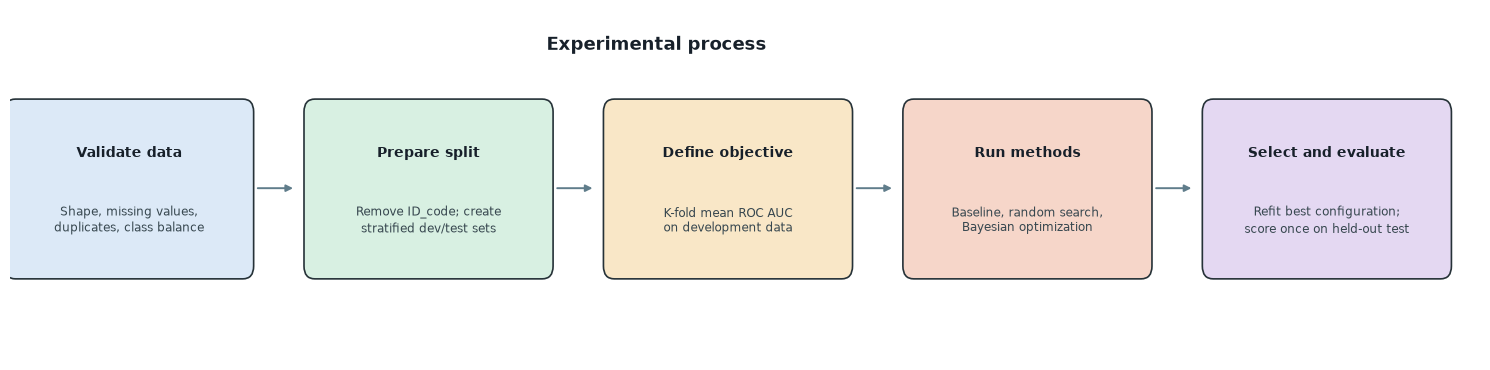

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

steps = [
    ("Validate data", "Shape, missing values,\nduplicates, class balance", "#dce9f7"),
    ("Prepare split", "Remove ID_code; create\nstratified dev/test sets", "#d8f0e2"),
    ("Define objective", "K-fold mean ROC AUC\non development data", "#f9e7c7"),
    ("Run methods", "Baseline, random search,\nBayesian optimization", "#f6d6c9"),
    ("Select and evaluate", "Refit best configuration;\nscore once on held-out test", "#e4d8f2"),
]

fig, ax = plt.subplots(figsize=(15, 3.8))
ax.set_xlim(0, len(steps) * 2.2 - 0.2)
ax.set_ylim(0, 2.2)
ax.axis("off")

for index, (title, detail, color) in enumerate(steps):
    x = index * 2.2
    box = FancyBboxPatch(
        (x, 0.55), 1.75, 1.05,
        boxstyle="round,pad=0.04,rounding_size=0.08",
        linewidth=1.2, edgecolor="#263238", facecolor=color
    )
    ax.add_patch(box)
    ax.text(x + 0.875, 1.30, title, ha="center", va="center",
            fontsize=10, fontweight="bold", color="#17202a")
    ax.text(x + 0.875, 0.88, detail, ha="center", va="center",
            fontsize=8.5, color="#37474f", linespacing=1.35)
    if index < len(steps) - 1:
        ax.annotate(
            "", xy=(x + 2.10, 1.08), xytext=(x + 1.80, 1.08),
            arrowprops={"arrowstyle": "-|>", "lw": 1.4, "color": "#607d8b"}
        )

ax.text(4.75, 1.98, "Experimental process", ha="center", va="center",
        fontsize=13, fontweight="bold", color="#17202a")
plt.tight_layout()
plt.show()
